# EDA: Kvasir-SEG

Разведочный анализ датасета сегментации полипов.

Что смотрим:
1. Количество примеров в train/val.
2. Распределение размеров изображений.
3. Распределение доли площади маски (полип vs фон).
4. Примеры image / mask / annotated.

In [3]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from src.config import load_config
from src.data.dataset import read_split_file

cfg = load_config(ROOT / 'configs' / 'config.yaml')
DATA_DIR = cfg.resolve_path(cfg.paths.data_dir)
IMG_DIR = DATA_DIR / 'images'
MASK_DIR = DATA_DIR / 'masks'
ANNOT_DIR = DATA_DIR / 'annotated_images'
print('DATA_DIR:', DATA_DIR)

DATA_DIR: /home/vitalikaff/dpo/dpo/project/data/Kvasir-SEG


In [4]:
train_list = read_split_file(DATA_DIR / 'train.txt')
val_list = read_split_file(DATA_DIR / 'val.txt')
print(f'Train: {len(train_list)} | Val: {len(val_list)} | Total: {len(train_list) + len(val_list)}')

Train: 880 | Val: 120 | Total: 1000


In [5]:
def collect_shapes(file_list, img_dir, limit=None):
    shapes = []
    files = file_list if limit is None else file_list[:limit]
    for name in files:
        img = cv2.imread(str(img_dir / name))
        if img is None:
            continue
        shapes.append(img.shape[:2])
    return np.array(shapes)

shapes_train = collect_shapes(train_list, IMG_DIR)
shapes_val = collect_shapes(val_list, IMG_DIR)
print('Train H,W stats:', shapes_train.mean(axis=0), shapes_train.min(axis=0), shapes_train.max(axis=0))
print('Val H,W stats:  ', shapes_val.mean(axis=0), shapes_val.min(axis=0), shapes_val.max(axis=0))

Train H,W stats: [543.51363636 620.97840909] [352 332] [1070 1348]
Val H,W stats:   [557.8   656.925] [429 481] [1072 1920]


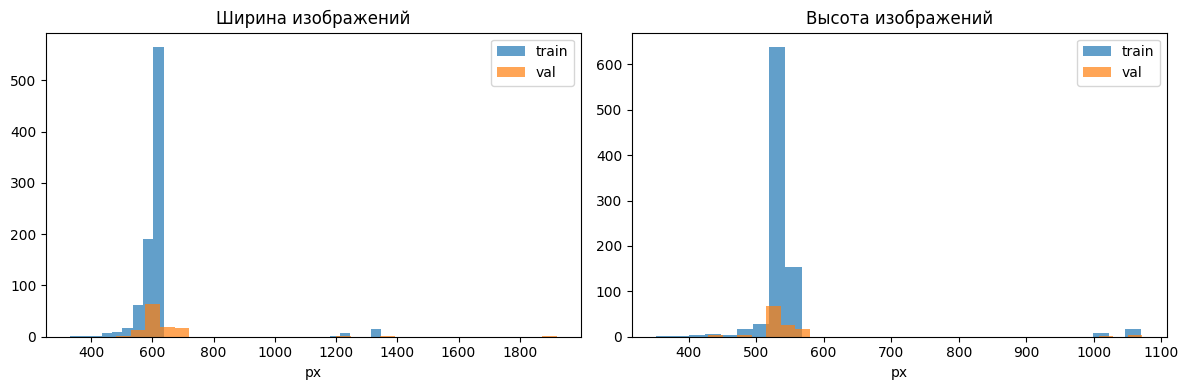

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(shapes_train[:, 1], bins=30, alpha=0.7, label='train')
axes[0].hist(shapes_val[:, 1], bins=30, alpha=0.7, label='val')
axes[0].set_title('Ширина изображений')
axes[0].set_xlabel('px'); axes[0].legend()
axes[1].hist(shapes_train[:, 0], bins=30, alpha=0.7, label='train')
axes[1].hist(shapes_val[:, 0], bins=30, alpha=0.7, label='val')
axes[1].set_title('Высота изображений')
axes[1].set_xlabel('px'); axes[1].legend()
plt.tight_layout()
plt.show()

Train mask area ratio: mean=0.154 median=0.114
Val   mask area ratio: mean=0.153 median=0.117


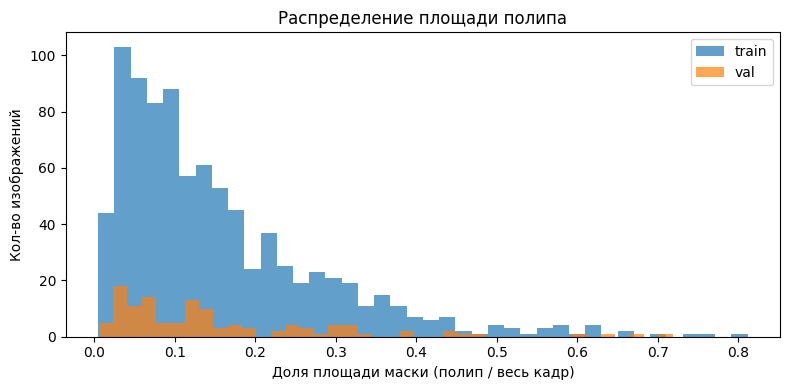

In [7]:
def mask_area_ratios(file_list, mask_dir):
    ratios = []
    for name in file_list:
        m = cv2.imread(str(mask_dir / name), cv2.IMREAD_GRAYSCALE)
        if m is None:
            continue
        binary = (m > 127).astype(np.uint8)
        ratios.append(binary.mean())
    return np.array(ratios)

ratios_train = mask_area_ratios(train_list, MASK_DIR)
ratios_val = mask_area_ratios(val_list, MASK_DIR)
print(f'Train mask area ratio: mean={ratios_train.mean():.3f} median={np.median(ratios_train):.3f}')
print(f'Val   mask area ratio: mean={ratios_val.mean():.3f} median={np.median(ratios_val):.3f}')

plt.figure(figsize=(8, 4))
plt.hist(ratios_train, bins=40, alpha=0.7, label='train')
plt.hist(ratios_val, bins=40, alpha=0.7, label='val')
plt.xlabel('Доля площади маски (полип / весь кадр)')
plt.ylabel('Кол-во изображений')
plt.title('Распределение площади полипа')
plt.legend(); plt.tight_layout(); plt.show()

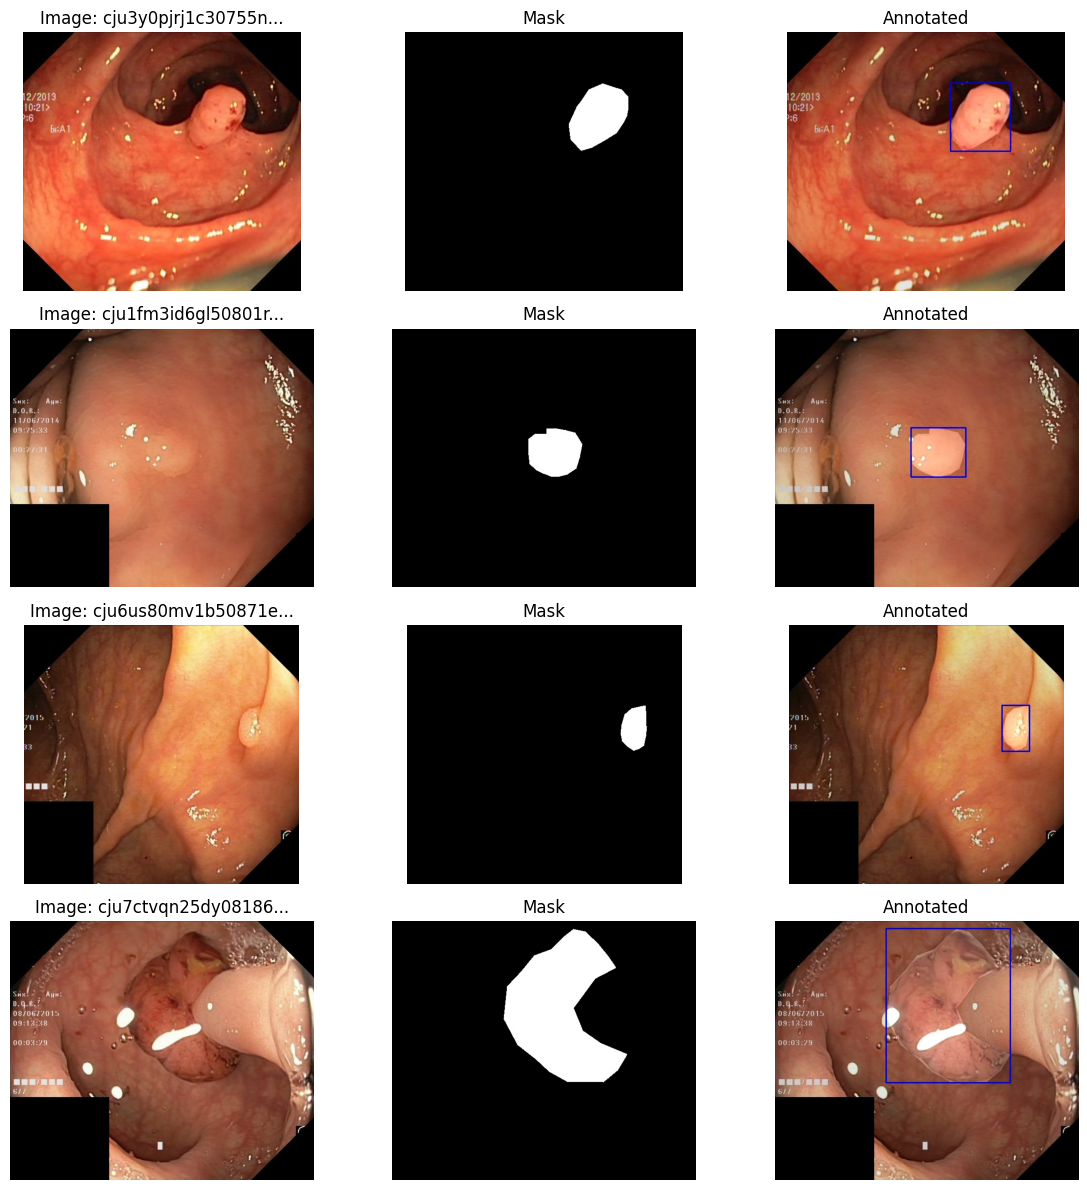

In [8]:
def show_examples(file_list, n=4, seed=0):
    rng = np.random.default_rng(seed)
    picks = rng.choice(len(file_list), size=n, replace=False)
    fig, axes = plt.subplots(n, 3, figsize=(12, 3 * n))
    for row, idx in enumerate(picks):
        name = file_list[idx]
        img = cv2.cvtColor(cv2.imread(str(IMG_DIR / name)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(MASK_DIR / name), cv2.IMREAD_GRAYSCALE)
        annot_path = ANNOT_DIR / name
        annot = cv2.cvtColor(cv2.imread(str(annot_path)), cv2.COLOR_BGR2RGB) if annot_path.exists() else img
        axes[row, 0].imshow(img); axes[row, 0].set_title(f'Image: {name[:18]}...'); axes[row, 0].axis('off')
        axes[row, 1].imshow(mask, cmap='gray'); axes[row, 1].set_title('Mask'); axes[row, 1].axis('off')
        axes[row, 2].imshow(annot); axes[row, 2].set_title('Annotated'); axes[row, 2].axis('off')
    plt.tight_layout(); plt.show()

show_examples(train_list, n=4, seed=42)

## Краткие выводы

- Размер сплитов: ~880 train / ~120 val (фиксированный сплит от авторов датасета).
- Изображения сильно разнятся по разрешению - поэтому в препроцессинге фиксируем 224×224.
- Доля площади маски сильно скошена влево: чаще всего полип занимает <20% кадра, есть несколько кадров без видимого полипа. Это мотивирует использовать BCE + Dice loss.